In [9]:
import numpy as np
import matplotlib.pyplot as plt
import taichi as ti
#ti.init(arch=ti.cpu)
ti.init(arch=ti.cuda)
import tqdm

[Taichi] Starting on arch=cuda


In [10]:
a = 1.0
m = 1.0              
k = 100.0            
ko = 100.0          
fmax = 0.1 * ko * a  
damping_ratio = 0.05
eta = 2.0 * np.sqrt(k * m) * damping_ratio
mu = 0.0

amp = 1e-1  
omega = np.sqrt(k / m)
periodicity = 2.0 * np.pi / omega
t_step = 50
dt = periodicity / t_step

total_step = 4000


# ==========================================

g = -0.2
y_ground = -0.05 * a

diss_y = 0.4     
diss_x = 0.8     

In [11]:
# %%
N_nodes = 8

# 3D Coordinates  Cube
# Bottom face (y=0)0123 Top face (y=a)4567
nodes_np = np.array([
    [0.0, 0.0, 0.0], [a, 0.0, 0.0], [a, 0.0, a], [0.0, 0.0, a],
    [0.0, a, 0.0],   [a, a, 0.0],   [a, a, a],   [0.0, a, a]
], dtype=np.float32)

# 4*3 Edges
bonds_structural = [
    [0,1], [1,2], [2,3], [3,0], # Bottom edges
    [4,5], [5,6], [6,7], [7,4], # Top edges
    [0,4], [1,5], [2,6], [3,7]  # Vertical pillars
]

# 12 Face Diagonals 
bonds_diagonal = [
    [0,2], [1,3], # Bottom 
    [4,6], [5,7], # Top 
    [0,5], [1,4], # Front 
    [1,6], [2,5], # Right 
    [2,7], [3,6], # Back 
    [3,4], [0,7]  # Left 
]

bonds_list = bonds_structural + bonds_diagonal
bonds_np = np.array(bonds_list, dtype=np.int32)
N_bonds = len(bonds_np)


rest_length_np = np.zeros(N_bonds, dtype=np.float32)
for i, (n1, n2) in enumerate(bonds_np):
    dx = nodes_np[n1, 0] - nodes_np[n2, 0]
    dy = nodes_np[n1, 1] - nodes_np[n2, 1]
    dz = nodes_np[n1, 2] - nodes_np[n2, 2]
    rest_length_np[i] = np.sqrt(dx**2 + dy**2 + dz**2)


odd_pairs_np = np.array([
    [12, 13], # Bottom face engine
    [14, 15], # Top face engine
    [16, 17], # Front face engine
    [18, 19], # Right face engine
    [20, 21], # Back face engine
    [22, 23]  # Left face engine
], dtype=np.int32)
N_odd_pairs = len(odd_pairs_np)

vel_np = np.zeros((N_nodes, 3), dtype=np.float32)

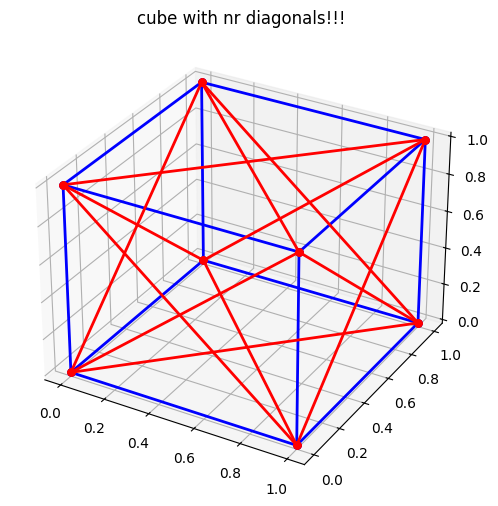

In [12]:
# %%

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

for idx, (i, j) in enumerate(bonds_np):
    color = "red" if idx >= len(bonds_structural) else "blue" 
    ax.plot(
        [nodes_np[i, 0], nodes_np[j, 0]],
        [nodes_np[i, 1], nodes_np[j, 1]],
        [nodes_np[i, 2], nodes_np[j, 2]],
        "-o", color=color, linewidth=2, markersize=5
    )

ax.set_title("cube with nr diagonals!!!")
plt.show()

In [13]:
# taichi velden met 3d vectors


pos = ti.Vector.field(3, dtype=ti.f32, shape=N_nodes)
vel = ti.Vector.field(3, dtype=ti.f32, shape=N_nodes)
force = ti.Vector.field(3, dtype=ti.f32, shape=N_nodes)

bonds = ti.Vector.field(2, dtype=ti.i32, shape=N_bonds)
rest_length = ti.field(dtype=ti.f32, shape=N_bonds)
extension = ti.field(dtype=ti.f32, shape=N_bonds)
tension = ti.field(dtype=ti.f32, shape=N_bonds)

odd_pairs = ti.Vector.field(2, dtype=ti.i32, shape=N_odd_pairs)

pos_record = ti.Vector.field(3, dtype=ti.f32, shape=(total_step, N_nodes))
vel_record = ti.Vector.field(3, dtype=ti.f32, shape=(total_step, N_nodes))
extension_record = ti.field(dtype=ti.f32, shape=(total_step, N_bonds))
tension_record = ti.field(dtype=ti.f32, shape=(total_step, N_bonds))

pos.from_numpy(nodes_np)
vel.from_numpy(vel_np)
bonds.from_numpy(bonds_np)
rest_length.from_numpy(rest_length_np)
odd_pairs.from_numpy(odd_pairs_np)

def pertubation(amp_value=amp):
    global nodes_np, vel_np
    nodes_np = np.array([
        [0.0, 0.0, 0.0], [a, 0.0, 0.0], [a, 0.0, a], [0.0, 0.0, a],
        [0.0, a, 0.0],   [a, a, 0.0],   [a, a, a],   [0.0, a, a]
    ], dtype=np.float32)
    
    nodes_np[:, 1] += 0.1 * a

    # Nudge
    nodes_np[6, 1] += amp_value
    nodes_np[6, 0] -= amp_value * 0.5
    nodes_np[6, 2] += amp_value * 0.5
    
    vel_np = np.zeros((N_nodes, 3), dtype=np.float32)
    pos.from_numpy(nodes_np)
    vel.from_numpy(vel_np)

@ti.func
def clamp(x, xmin, xmax):
    return ti.min(ti.max(x, xmin), xmax)

@ti.kernel
def zero_force():
    for i in range(N_nodes):
        # 3D Gravity Vector!
        force[i] = ti.Vector([0.0, m * g, 0.0])

@ti.kernel
def nodal_f_passive():
    for b in range(N_bonds):
        i = bonds[b][0]
        j = bonds[b][1]
        rij = pos[j] - pos[i]
        lij = rij.norm()
        if lij > 1e-8:
            eij = rij / lij
            dl = lij - rest_length[b]
            extension[b] = dl
            vij = vel[j] - vel[i]
            dl_dt = vij.dot(eij)
            T = k * dl + eta * dl_dt
            tension[b] = T
            force[i] += T * eij
            force[j] -= T * eij

@ti.func
def apply_bond_tension(b: ti.i32, T: ti.f32):
    i = bonds[b][0]
    j = bonds[b][1]
    r = pos[j] - pos[i]
    e = r / r.norm()
    force[i] += T * e
    force[j] -= T * e

@ti.kernel
def nodal_f_active():
    for p in range(N_odd_pairs):
        b1 = odd_pairs[p][0]
        b2 = odd_pairs[p][1]
        d1 = extension[b1]
        d2 = extension[b2]
        T1 = clamp(ko * d2, -fmax, fmax)
        T2 = clamp(-ko * d1, -fmax, fmax)
        tension[b1] += T1
        tension[b2] += T2
        apply_bond_tension(b1, T1)
        apply_bond_tension(b2, T2)

@ti.kernel
def update():
    for i in range(N_nodes):
        force[i] += -mu * vel[i]
        old_v = vel[i] + dt * force[i] / m
        old_x = pos[i]
        new_x = old_x + old_v * dt
        toi = 0.0
        new_v = old_v

        if new_x[1] < y_ground and old_v[1] < -1e-6:
            toi = (old_x[1] - y_ground) / (-old_v[1])
            toi = ti.min(ti.max(toi, 0.0), dt)
            
            # collisions
            new_v = ti.Vector([
                diss_x * old_v[0],
                -diss_y * old_v[1],
                diss_x * old_v[2]
            ])
            new_x = old_x + toi * old_v + (dt - toi) * new_v

        if new_x[1] < y_ground:
            new_x[1] = y_ground
            if new_v[1] < 0.0:
                new_v[1] = 0.0

        vel[i] = new_v
        pos[i] = new_x

@ti.kernel
def data_record(frame: ti.i32):
    for i in range(N_nodes):
        pos_record[frame, i] = pos[i]
        vel_record[frame, i] = vel[i]
    for b in range(N_bonds):
        extension_record[frame, b] = extension[b]
        tension_record[frame, b] = tension[b]

In [14]:
# -sim loop
pertubation(amp_value=amp)

zero_force()
nodal_f_passive()
nodal_f_active()
data_record(0)

for ii in tqdm.tqdm(range(total_step - 1), desc="Simulating"):
    zero_force()
    nodal_f_passive()
    nodal_f_active()
    update()
    data_record(ii + 1)

Simulating: 100%|██████████| 3999/3999 [00:03<00:00, 1060.75it/s]


In [16]:
# -rendering

def video(plt_step=1, close=1, save=0):
    pos_np = pos_record.to_numpy()[::plt_step]
    N_step = len(pos_np)

    # 3D Ground 
    ground_size = 10.0 * a
    ground_vertices = ti.Vector.field(3, dtype=ti.f32, shape=4)
    ground_indices = ti.field(dtype=ti.i32, shape=8) 
    
    # Square on the floor
    ground_vertices.from_numpy(np.array([
        [-ground_size, y_ground, -ground_size],
        [ ground_size, y_ground, -ground_size],
        [ ground_size, y_ground,  ground_size],
        [-ground_size, y_ground,  ground_size],
    ], dtype=np.float32))
    
    # Lines bound floor
    ground_indices.from_numpy(np.array([
        0, 1, 1, 2, 2, 3, 3, 0
    ], dtype=np.int32))

    window = ti.ui.Window(f"3D Odd Lattice Cube", (800, 600), vsync=True)
    canvas = window.get_canvas()
    canvas.set_background_color((1, 1, 1))

    scene = window.get_scene()
    camera = ti.ui.Camera()
    gui = window.get_gui()

    # --- 1. INITIALIZE VIDEO MANAGER ---
    if save:
        video_manager = ti.tools.VideoManager(output_dir="./output_video", framerate=30, automatic_build=False)

    pause = False
    step = 0

    while window.running:
        # Dynamic Camera Tracking in 3D
        center_x = np.mean(pos_np[step, :, 0])
        center_y = np.mean(pos_np[step, :, 1])
        center_z = np.mean(pos_np[step, :, 2])
        
        # Position camera back and up slightly, looking at the center of the cube
        camera.position(center_x + 3.0*a, center_y + 2.0*a, center_z + 4.0*a)
        camera.lookat(center_x, center_y, center_z)
        camera.up(0.0, 1.0, 0.0)
        scene.set_camera(camera)

        scene.ambient_light((0.6, 0.6, 0.6))
        scene.point_light(pos=(center_x + a, center_y + 3*a, center_z + a), color=(1, 1, 1))

        for e in window.get_events(ti.ui.PRESS):
            if e.key == ti.ui.ESCAPE:
                window.running = False
            elif e.key == ti.ui.SPACE:
                pause = not pause

        if window.is_pressed("r"): step = 0
        if window.is_pressed("z"): step += 10
        if window.is_pressed("x"): step -= 10
        step = max(0, min(step, N_step - 1))

        with gui.sub_window("Simulation", 0.00, 0.88, 0.45, 0.12) as w:
            w.text(f"frame: {step}/{N_step - 1}")
            w.text(f"physical step: {step * plt_step * t_step}")

        # Render ground
        scene.lines(vertices=ground_vertices, indices=ground_indices, color=(0.1, 0.25, 0.85), width=2.0)

        current_pos_field = ti.Vector.field(3, dtype=ti.f32, shape=N_nodes)
        
        # Ghost starting position
        current_pos_field.from_numpy(pos_np[0])
        scene.lines(vertices=current_pos_field, indices=bonds_ti, color=(0.8, 0.8, 0.8), width=1.5)

        # Current
        current_pos_field.from_numpy(pos_np[step])
        scene.lines(vertices=current_pos_field, indices=bonds_ti, color=(0.1, 0.1, 0.1), width=4.0)

        # Current nodes
        scene.particles(current_pos_field, radius=0.045 * a, color=(0.9, 0.2, 0.1))

        # Motion Blur tails
        tail_num = 10
        tail_gap = 2
        for i in range(tail_num):
            step_i = step - i * tail_gap
            if step_i >= 0:
                current_pos_field.from_numpy(pos_np[step_i])
                scene.particles(
                    current_pos_field,
                    radius=0.035 * a * (1.0 - 0.05 * i),
                    color=(1.0, 0.2 + 0.05 * i, 0.2 + 0.05 * i),
                )

        canvas.scene(scene)

        # --- 2. CAPTURE FRAME ---
        # Must be called BEFORE window.show() clears the buffer
        if save and not pause:
            img = window.get_image_buffer_as_numpy()
            video_manager.write_frame(img)

        window.show()

        if not pause: step += 1
        if step >= N_step:
            if close == 1: window.running = False
            else:
                step = N_step - 1
                pause = True
                
    # --- 3. COMPILE VIDEO ON EXIT ---
    if save:
        print("Compiling video...")
        video_manager.make_video(gif=False, mp4=True)
        print("Done! Video saved to ./output_video")

# Run the function, set close=1 and save=1 to generate the MP4.
video(plt_step=1, close=1, save=1)

Compiling video...
Done! Video saved to ./output_video
